## WeGo Data Introduction

In [4]:
import pandas as pd

In [5]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [6]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In the data, the bus route can be identified by its ROUTE_ABBR value.  
**3:** West End  
**7:** Hillsboro  
**22:** Bordeaux  
**23:** Dickerson Pike  
**50:** Charlotte Pike  
**52:** Nolensville Pike  
**55:** Murfreesboro Pike  
**56:** Gallatin Pike

In [7]:
wego['ROUTE_ABBR'].value_counts().sort_index()

ROUTE_ABBR
3     47162
7     18026
22    25959
23    42108
50    43291
52    51819
55    61944
56    60020
Name: count, dtype: int64

The trip can be identified by the DATE/CALENDAR_ID plus the TRIP_ID.  
**Warning:** The TRIP_ID refers to the route and time but will be used across multiple days.

The data contains multiple **time points** for each trip. There are more stops along the route than time points, but the time points are the points with specific scheduled times the bus operators must adhere to.

The first stop of a trip has a TRIP_EDGE of 1, the last has a TRIP_EDGE of 2, and the intermediate stops are TRIP_EDGE 0. 

Here is the first trip in the dataset. It was a Bordeaux route (Route 22), scheduled to start at 4:42:00 and end at 5:10:00.

In [8]:
wego[['DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR', 'TIME_POINT_ABBR', 'TRIP_EDGE', 'SCHEDULED_TIME']].loc[:3]

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME
0,2023-08-01,120230801,345104,22,MHSP,1,2023-08-01 04:42:00
1,2023-08-01,120230801,345104,22,ELIZ,0,2023-08-01 04:46:00
2,2023-08-01,120230801,345104,22,CV23,0,2023-08-01 04:54:00
3,2023-08-01,120230801,345104,22,MCC5_10,2,2023-08-01 05:10:00


Note that the same TRIP_ID appears on the following day.

In [9]:
(
    wego
    .loc[wego['DATE'].astype(str).isin(['2023-08-01', '2023-08-02'])]
    .loc[wego['TRIP_ID'] == 345104]
    [['DATE', 'ROUTE_ABBR', 'TRIP_ID', 'TIME_POINT_ABBR', 'TRIP_EDGE', 'ROUTE_DIRECTION_NAME', 'SCHEDULED_TIME', 'ROUTE_STOP_SEQUENCE']]
)

,DATE,ROUTE_ABBR,TRIP_ID,TIME_POINT_ABBR,TRIP_EDGE,ROUTE_DIRECTION_NAME,SCHEDULED_TIME,ROUTE_STOP_SEQUENCE
0,2023-08-01,22,345104,MHSP,1,TO DOWNTOWN,2023-08-01 04:42:00,14.0
1,2023-08-01,22,345104,ELIZ,0,TO DOWNTOWN,2023-08-01 04:46:00,10.0
2,2023-08-01,22,345104,CV23,0,TO DOWNTOWN,2023-08-01 04:54:00,5.0
3,2023-08-01,22,345104,MCC5_10,2,TO DOWNTOWN,2023-08-01 05:10:00,1.0
6461,2023-08-02,22,345104,MHSP,1,TO DOWNTOWN,2023-08-02 04:42:00,14.0
6462,2023-08-02,22,345104,ELIZ,0,TO DOWNTOWN,2023-08-02 04:46:00,10.0
6463,2023-08-02,22,345104,CV23,0,TO DOWNTOWN,2023-08-02 04:54:00,5.0
6464,2023-08-02,22,345104,MCC5_10,2,TO DOWNTOWN,2023-08-02 05:10:00,1.0


**Adherence** refers to the difference between scheduled time and the actual time that the bus departs from a stop.

A negative value for ADHERENCE indicates that the bus is late, and a positive indicates that the bus is early.

Generally, an adherence value less than -6 is considered late, and greater than 1 is considered early, but there are some exceptions. For example, a positive adherence for the end of a trip (TRIP_EDGE 2) is not considered early, since it is not a problem if a bus ends its trip early as long as it didn't pass other timepoints early along the way. You can check whether a trip was considered on-time, early, or late using the ADJUSTED_EARLY_COUNT, ADJUSTED_LATE_COUNT, and ADJUSTED_ONTIME_COUNT columns.

Here is an example of a trip where all time points would be considered to be on time. Notice that at the end of the trip, the bus was more than 6 minutes early, but was still counted as on-time since this was a trip edge of 2.

In [11]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[:3]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,2023-08-01,120230801,345104,22,MHSP,1,2023-08-01 04:42:00,2023-08-01 04:44:08,-2.133333,0,0,1
1,2023-08-01,120230801,345104,22,ELIZ,0,2023-08-01 04:46:00,2023-08-01 04:48:27,-2.450000,0,0,1
2,2023-08-01,120230801,345104,22,CV23,0,2023-08-01 04:54:00,2023-08-01 04:54:56,-0.933333,0,0,1
3,2023-08-01,120230801,345104,22,MCC5_10,2,2023-08-01 05:10:00,2023-08-01 05:03:43,6.283333,0,0,1


And one that has one late stop.

In [13]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[77:79]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
77,2023-08-01,120230801,345127,22,MHSP,1,2023-08-01 17:05:00,2023-08-01 17:08:21,-3.350000,0,0,1
78,2023-08-01,120230801,345127,22,CV23,0,2023-08-01 17:14:00,2023-08-01 17:20:10,-6.166666,0,1,0
79,2023-08-01,120230801,345127,22,MCC5_10,2,2023-08-01 17:30:00,2023-08-01 17:30:23,-0.383333,0,0,1


And one which was early.

In [14]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[11:13]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
11,2023-08-01,120230801,345107,22,MCC5_10,1,2023-08-01 06:15:00,2023-08-01 06:16:19,-1.316666,0,0,1
12,2023-08-01,120230801,345107,22,CV23,0,2023-08-01 06:25:00,2023-08-01 06:23:30,1.500000,1,0,0
13,2023-08-01,120230801,345107,22,MHSP,2,2023-08-01 06:35:00,2023-08-01 06:30:59,4.016666,0,0,1


**Headway** is the amount of time between a bus and the prior bus at the same stop. In the dataset, the amount of headway scheduled is contained in the SCHEDULED_HDWY column and indicates the difference between the scheduled time for a particular stop and the scheduled time for the previous bus on that same stop.

This dataset contains a column HDWY_DEV, which shows the amount of deviation from the scheduled headway. **Bunching** occurs when there is shorter headway than scheduled, which would appear as a negative HDWY_DEV value. **Gapping** is when there is more headway than scheduled and appears as a positive value in the HDWY_DEV column. Note that you can calculate headway deviation percentage as HDWY_DEV/SCHEDULED_HDWY. 

The generally accepted range of headway deviation is 50% to 150% of the scheduled headway, so if scheduled headway is 10 minutes, a headway deviation of up to 5 minutes would be acceptable (but not ideal).

In [15]:
(
    wego
    .loc[wego['ROUTE_ABBR'] == 22]
    .loc[wego['ROUTE_DIRECTION_NAME'] == 'TO DOWNTOWN']
    .loc[wego['TIME_POINT_ABBR'] == 'CV23']
    [['DATE', 'TRIP_ID', 'TIME_POINT_ABBR','ROUTE_DIRECTION_NAME', 'TRIP_EDGE', 
      'SCHEDULED_TIME', 'SCHEDULED_HDWY',
      'ACTUAL_DEPARTURE_TIME', 'ACTUAL_HDWY', 'HDWY_DEV'
     ]]
    .sort_values(['DATE', 'SCHEDULED_TIME'])
    .iloc[:5]
)

,DATE,TRIP_ID,TIME_POINT_ABBR,ROUTE_DIRECTION_NAME,TRIP_EDGE,SCHEDULED_TIME,SCHEDULED_HDWY,ACTUAL_DEPARTURE_TIME,ACTUAL_HDWY,HDWY_DEV
2,2023-08-01,345104,CV23,TO DOWNTOWN,0,2023-08-01 04:54:00,NaN,2023-08-01 04:54:56,NaN,NaN
126,2023-08-01,345213,CV23,TO DOWNTOWN,0,2023-08-01 05:19:00,25.0,2023-08-01 05:18:59,24.050000,-0.950000
402,2023-08-01,345405,CV23,TO DOWNTOWN,0,2023-08-01 05:39:00,20.0,2023-08-01 05:39:40,20.683333,0.683333
9,2023-08-01,345106,CV23,TO DOWNTOWN,0,2023-08-01 05:54:00,15.0,2023-08-01 05:54:11,14.516666,-0.483334
316,2023-08-01,345377,CV23,TO DOWNTOWN,0,2023-08-01 06:09:00,15.0,2023-08-01 06:10:01,15.833333,0.833333


Two other columns that you've been asked to explore are the DWELL_IN_MINS column and SCHEDULED_LAYOVER_MINUTES, which shows the difference between actual arrival and actual departure time at a time point and the time a bus was scheduled to arrive at the time point and when it is scheduled to leave at the beginning of a trip.

Here, we can see the end of the first trip in the dataset and the beginning of the next trip, which goes in the opposite direction.

In [16]:
wego.loc[3:4, ['DATE', 'TRIP_ID', 'TRIP_EDGE', 'TIME_POINT_ABBR',
               'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES']]

,DATE,TRIP_ID,TRIP_EDGE,TIME_POINT_ABBR,ACTUAL_ARRIVAL_TIME,ACTUAL_DEPARTURE_TIME,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
3,2023-08-01,345104,2,MCC5_10,2023-08-01 05:03:43,2023-08-01 05:03:43,0.000000,NaN
4,2023-08-01,345105,1,MCC5_10,2023-08-01 05:03:43,2023-08-01 05:16:35,12.866666,5.0


## Group Project Start

In [17]:
wego.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350329 entries, 0 to 350328
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CALENDAR_ID                350329 non-null  int64  
 1   SERVICE_ABBR               350329 non-null  int64  
 2   ADHERENCE_ID               350329 non-null  int64  
 3   DATE                       350329 non-null  object 
 4   ROUTE_ABBR                 350329 non-null  int64  
 5   BLOCK_ABBR                 350329 non-null  int64  
 6   OPERATOR                   350329 non-null  int64  
 7   TRIP_ID                    350329 non-null  int64  
 8   OVERLOAD_ID                350329 non-null  int64  
 9   ROUTE_DIRECTION_NAME       350329 non-null  object 
 10  TIME_POINT_ABBR            350329 non-null  object 
 11  ROUTE_STOP_SEQUENCE        350318 non-null  float64
 12  TRIP_EDGE                  350329 non-null  int64  
 13  LATITUDE                   35

In [18]:
wego.head(40)

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0
5,120230801,1,99457895,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
6,120230801,1,99457896,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
7,120230801,1,99457897,2023-08-01,22,2200,1040,345106,0,TO DOWNTOWN,...,37.666666,2.666666,0,0,1,0,0.0,0,13.216666,10.0
8,120230801,1,99457898,2023-08-01,22,2200,1040,345106,0,TO DOWNTOWN,...,36.966666,1.966666,0,0,1,0,0.0,0,0.000000,NaN
9,120230801,1,99457899,2023-08-01,22,2200,1040,345106,0,TO DOWNTOWN,...,14.516666,-0.483334,0,0,1,0,0.0,0,0.000000,NaN


## Q1  What is the overall on-time performance, and what do the overall distribution of adherence look like?

In [37]:
# Cell 1 Q1
import matplotlib.pyplot as plt
import numpy as np


In [48]:
# Cell 2 Q1

# Create a copy of the DataFrame
workingtable = wego.copy()

# Add a column for on-time status (1 for on-time, 0 for not on-time)
# On-time is defined as ADHERENCE between -5 and 0 minutes (inclusive)
workingtable['ON_TIME'] = np.where(
    (workingtable['ADHERENCE'].notnull()) & (workingtable['ADHERENCE'].between(-6, 6)),
    1,
    0
)

# Calculate overall on-time performance
total_count = workingtable['ADHERENCE'].notnull().sum()  # Count non-null ADHERENCE values
ontime_count = workingtable['ON_TIME'].sum()  # Sum of on-time stops
ontime_perc = (ontime_count / total_count) * 100

workingtable.head()


,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES,ON_TIME
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,0.0,0,6.500000,NaN,1
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,0.0,0,0.000000,NaN,1
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,0.0,0,0.000000,NaN,1
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,NaN,0,0.000000,NaN,0
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,0,0,1,0,0.0,0,12.866666,5.0,1


In [49]:
# Cell 3 Q1

print(f"Overall On-Time Performance: {ontime_perc:.2f}%")

Overall On-Time Performance: 81.75%


In [50]:
print(f"On-Time Stops: {ontime_count} \n Total Stops: {total_count}")

On-Time Stops: 277030 
 Total Stops: 338861


In [51]:
# Cell 4 Q1 exploratory w/ adjusted ontime compared to ontime calc from cell 2

adjusted_ontime_count = workingtable['ADJUSTED_ONTIME_COUNT'].sum()
print(adjusted_ontime_count)
print(ontime_count)

270048
277030


-6 Late vs 1+ is early   exceptions or 2 in trippage is considered end of trip.

In [77]:
# Cell 5 Q1  (Probably the only cell we actually needed)

# Grouped to the stop type

trip_edge_counts = workingtable.groupby('TRIP_EDGE').agg({
    'ADJUSTED_EARLY_COUNT': 'sum',
    'ADJUSTED_LATE_COUNT': 'sum',
    'ADJUSTED_ONTIME_COUNT': 'sum'
}).reset_index()

# Keep It Simple Stupid

trip_edge_counts = trip_edge_counts.rename(columns={
    'ADJUSTED_EARLY_COUNT': 'EARLY',
    'ADJUSTED_LATE_COUNT': 'LATE',
    'ADJUSTED_ONTIME_COUNT': 'ONTIME'
})

# Labels for reading stuff easy

trip_edge_counts['TRIP_EDGE'] = trip_edge_counts['TRIP_EDGE'].map({
    0: 'Middle Run',
    1: 'First Stop',
    2: 'Last Stop'
})

# Ordered for mah viewing pleasure

trip_edge_counts = trip_edge_counts[['TRIP_EDGE', 'EARLY', 'LATE', 'ONTIME']]

# hava looky see

print(trip_edge_counts)

    TRIP_EDGE  EARLY   LATE  ONTIME
0  Middle Run   7952  40423  159497
1  First Stop   1081   6210   58421
2   Last Stop    742  12405   52130


In [84]:
# Just checking to make sure my visuals are on point

# Count distinct TRIP_ID for August 2, 2023
distinct_trips = workingtable[workingtable['DATE'].isin(['2023-08-01', '2023-08-01'])]['OPERATOR'].nunique()
print(f"Number of distinct Operators on August 1, 2023: {distinct_trips}")
late_count_sum = workingtable[workingtable['DATE'].isin(['2023-08-01', '2023-08-01'])]['ADJUSTED_LATE_COUNT'].sum()
print(f"Sum of ADJUSTED_LATE_COUNT for late stops on August 1, 2023: {late_count_sum}")

Number of distinct Operators on August 1, 2023: 138
Sum of ADJUSTED_LATE_COUNT for late stops on August 1, 2023: 953


## Q2  How does direction of travel, route, or location affect the on-time performance?

In [64]:
#Cell 2 Q2

dir_ontime = (workingtable.groupby('ROUTE_DIRECTION_NAME')['ON_TIME'].mean() * 100).round(2)
route_ontime = (workingtable.groupby('ROUTE_ABBR')['ON_TIME'].mean() * 100).round(2).sort_values(ascending=False)
loc_ontime = (workingtable.groupby('TIME_POINT_ABBR')['ON_TIME'].mean() * 100).round(2).sort_values(ascending=False)

print(dir_ontime)
print(route_ontime)
print(loc_ontime)


ROUTE_DIRECTION_NAME
FROM DOWNTOWN    74.81
TO DOWNTOWN      83.90
Name: ON_TIME, dtype: float64
ROUTE_ABBR
50    86.29
23    85.41
22    85.04
56    82.61
3     75.82
7     75.70
52    75.61
55    70.18
Name: ON_TIME, dtype: float64
TIME_POINT_ABBR
MEIG       92.66
CV23       89.61
WALM       89.45
MHSP       88.57
DKTL       88.54
           ...  
MCC4_20    48.15
DCSCC      40.74
MCC5_12    34.88
MCC5_11    22.97
MCC5_7     11.11
Name: ON_TIME, Length: 61, dtype: float64


In [65]:
# Cell 3 Q2 Explore a lil bit

# Get the 5 highest and 5 lowest performing routes from route_ontime
route_ontime = (workingtable.groupby('ROUTE_ABBR')['ON_TIME'].mean() * 100).round(2).sort_values(ascending=False)
top_5_routes = route_ontime.head(5)
bottom_5_routes = route_ontime.tail(5)

# Function to get route details
def print_route_details(routes, title):
    print(f"\n{title}:")
    for route in routes.index:
        # Filter for the route
        route_data = workingtable[workingtable['ROUTE_ABBR'] == route]
        # Number of stops
        stop_count = len(route_data)
        # Unique stops (TIME_POINT_ABBR)
        unique_stops = route_data['TIME_POINT_ABBR'].unique()
        # Sample of scheduled times (first 5 for brevity)
        scheduled_times = route_data['SCHEDULED_TIME'].dropna().head(5).tolist()
        print(f"\nRoute {route} (On-Time: {routes[route]:.2f}%):")
        print(f"  Number of Stops: {stop_count}")
        print(f"  Stops: {', '.join(sorted(unique_stops))}")
        print(f"  Sample Scheduled Times: {', '.join(scheduled_times) if scheduled_times else 'None'}")

# Print details for top 5 and bottom 5 routes
print_route_details(top_5_routes, "Top 5 Performing Routes")
print_route_details(bottom_5_routes, "Bottom 5 Performing Routes")


Top 5 Performing Routes:

Route 50 (On-Time: 86.29%):
  Number of Stops: 43291
  Stops: 28&CHARL, CH46, HEAD, HLWD, MCC4_13, MCC4_20, MCC4_22, MCC5_1, MCC5_11, MCC5_2, MLKS, WALM, WHBG
  Sample Scheduled Times: 2023-08-01 04:39:00, 2023-08-01 04:45:00, 2023-08-01 04:52:00, 2023-08-01 04:55:00, 2023-08-01 04:59:00

Route 23 (On-Time: 85.41%):
  Number of Stops: 42108
  Stops: DKTL, DWMRT, EDBC, MCC4_24, N1SP
  Sample Scheduled Times: 2023-08-01 05:00:00, 2023-08-01 05:09:00, 2023-08-01 05:18:00, 2023-08-01 05:25:00, 2023-08-01 05:39:00

Route 22 (On-Time: 85.04%):
  Number of Stops: 25959
  Stops: 25ACLARK, CLFF, CRES, CV23, ELIZ, HPKL, MCC5_10, MCC5_2, MCC5_6, MHSP, YGKG
  Sample Scheduled Times: 2023-08-01 04:42:00, 2023-08-01 04:46:00, 2023-08-01 04:54:00, 2023-08-01 05:10:00, 2023-08-01 05:15:00

Route 56 (On-Time: 82.61%):
  Number of Stops: 60020
  Stops: GXFIVEPT, GXGRNFLD, GXMADISO, GXRVRGAT, MCC4_18, MCC4_20, MCC4_22, MCC5_7, MEIG, SAMS
  Sample Scheduled Times: 2023-08-01 04:

In [66]:
loc_ontime = (workingtable.groupby('TIME_POINT_ABBR')['ON_TIME'].mean() * 100).round(2)
loc_counts = workingtable.groupby('TIME_POINT_ABBR').size()

# Get the 5 stops with the lowest on-time performance
bottom_5_stops = loc_ontime.sort_values(ascending=True).head(5)

# Print details for the 5 least on-time stops
print("5 Stops with Highest Likelihood of Being Late (Lowest On-Time %):")
for stop in bottom_5_stops.index:
    stop_data = workingtable[workingtable['TIME_POINT_ABBR'] == stop]
    stop_count = loc_counts[stop]
    routes = sorted(stop_data['ROUTE_ABBR'].unique())
    ontime_pct = bottom_5_stops[stop]
    print(f"\nStop {stop} (On-Time: {ontime_pct:.2f}%):")
    print(f"  Number of Stops: {stop_count}")
    print(f"  Routes: {', '.join(map(str, routes))}")

5 Stops with Highest Likelihood of Being Late (Lowest On-Time %):

Stop MCC5_7 (On-Time: 11.11%):
  Number of Stops: 36
  Routes: 56

Stop MCC5_11 (On-Time: 22.97%):
  Number of Stops: 74
  Routes: 50, 55

Stop MCC5_12 (On-Time: 34.88%):
  Number of Stops: 43
  Routes: 7

Stop DCSCC (On-Time: 40.74%):
  Number of Stops: 2747
  Routes: 52

Stop MCC4_20 (On-Time: 48.15%):
  Number of Stops: 108
  Routes: 7, 50, 56


low ontime stops at particular locations with extremely low counts indicate the possibility of goegraphics playing a role in on-time percentages. will explore this more in Tabluea.

## Q3

## Q4

## Q5

In [45]:
# CELL 1


# For Question 5
relate = wego.copy()
relate['LATE'] = np.where(
    (relate['ADHERENCE'].notnull()) & (relate['ADHERENCE'] <= -6),
    'Yes',
    'No'
)
relate

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES,LATE
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,0.0,0,6.500000,NaN,No
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,0.0,0,0.000000,NaN,No
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,0.0,0,0.000000,NaN,No
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,0,0,1,0,NaN,0,0.000000,NaN,No
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,0,0,1,0,0.0,0,12.866666,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350324,120230930,2,100406610,2023-09-30,7,702,2312,353448,0,TO DOWNTOWN,...,5.266666,0,1,0,0,0.0,0,0.000000,NaN,Yes
350325,120230930,2,100406611,2023-09-30,7,702,2312,353448,0,TO DOWNTOWN,...,NaN,0,1,0,0,NaN,0,0.000000,NaN,Yes
350326,120230930,2,100406612,2023-09-30,7,702,2312,353449,0,FROM DOWNTOWN,...,1.866666,0,0,1,0,0.0,0,0.000000,NaN,No
350327,120230930,2,100406613,2023-09-30,7,702,2312,353449,0,FROM DOWNTOWN,...,17.500000,0,1,0,0,0.0,0,0.000000,NaN,Yes


In [46]:
# CELL 2

relate[relate['ADHERENCE'] <= -6][['ADHERENCE', 'HDWY_DEV']].corr()

,ADHERENCE,HDWY_DEV
ADHERENCE,1.000000,-0.019212
HDWY_DEV,-0.019212,1.000000


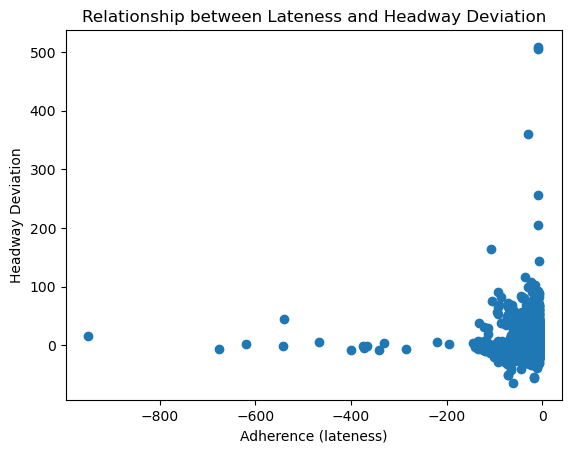

In [47]:
# CELL 3


late = relate[relate['ADHERENCE'] <= -6]
plt.scatter(late['ADHERENCE'], late['HDWY_DEV'])
plt.xlabel('Adherence (lateness)')
plt.ylabel('Headway Deviation')
plt.title('Relationship between Lateness and Headway Deviation')
plt.show()